In [1]:
import fire
import pickle
import json
import numpy as np
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
from ray import tune
from pytagi import metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    Optimizer,
    SKF,
    plot_data,
    plot_prediction,
    plot_skf_states,
    plot_states,
)
from canari.component import LocalTrend, LocalAcceleration, LstmNetwork, WhiteNoise

with open("../examples/benchmark/BM_metadata.json", "r") as f:
    metadata = json.load(f)
benchmark = "5"
config = metadata[benchmark]

/opt/miniconda3/envs/canari/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-26 15:11:36,352	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-26 15:11:36,478	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
data_file = "/Users/vuongdai/GitHub/canari/data/benchmark_data/test_5_data.csv"
df = pd.read_csv(data_file, skiprows=0, delimiter=",")
df.index = pd.to_datetime(df["date"])
df = df.drop(columns=["date"])
# df = df.interpolate()

column_name = "diplacement_y"
df_prophet = df[[column_name]].copy()
df_prophet["ds"] = df.index
df_prophet.columns = ["y", "ds"] 

nan_idx = np.where(df_prophet["y"].isna())[0]
df_prophet["y"] = df_prophet["y"].interpolate()

# Run Prophet
prophet_model = Prophet()
prophet_model.fit(df_prophet)
phophet_results = prophet_model.predict(df_prophet[["ds"]])

trend = phophet_results["trend"]
detrend_data = df_prophet["y"].values - trend.values
detrend_data[nan_idx] = np.nan
df[column_name] = detrend_data


15:11:37 - cmdstanpy - INFO - Chain [1] start processing
15:11:37 - cmdstanpy - INFO - Chain [1] done processing


In [3]:
df.head()

,diplacement_y,water_level,temp_min,temp_max
date,,,,
2010-02-07,-1.426141,31.15,-16.3,-7.4
2010-02-14,-1.336229,30.94,-9.1,0.6
2010-02-21,-1.316317,31.07,-6.0,2.0
2010-02-28,-1.266404,31.04,-0.1,5.0
2010-03-07,-1.246492,31.04,-5.9,9.2


In [4]:
df = DataProcess.add_lagged_columns(df, config["lag_vector"])
output_col = config["output_col"]
data_processor = DataProcess(
    data=df,
    time_covariates=config["time_covariates"],
    train_split=0.7,
    validation_split=0.3,
    output_col=output_col,
)
train_data, validation_data, _, all_data = data_processor.get_splits()

/Users/vuongdai/GitHub/canari/src/canari/data_process.py:417: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[f"{col.name}_lag{lag}"] = col.shift(lag).fillna(0)
/Users/vuongdai/GitHub/canari/src/canari/data_process.py:417: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[f"{col.name}_lag{lag}"] = col.shift(lag).fillna(0)
/Users/vuongdai/GitHub/canari/src/canari/data_process.py:417: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

In [5]:
model = Model(
        LstmNetwork(
            look_back_len=52,
            num_features=config["num_feature"],
            num_layer=2,
            infer_len=config["infer_len"],
            num_hidden_unit=50,
            # manual_seed=1,
            smoother=False,
        ),
        WhiteNoise(std_error=0.1),
    )

In [6]:
num_epoch = 100
for epoch in range(num_epoch):
    mu_validation_preds, std_validation_preds, states = model.lstm_train(
        train_data=train_data,
        validation_data=validation_data,
    )

    mu_validation_preds_unnorm = normalizer.unstandardize(
        mu_validation_preds,
        data_processor.scale_const_mean[data_processor.output_col],
        data_processor.scale_const_std[data_processor.output_col],
    )

    std_validation_preds_unnorm = normalizer.unstandardize_std(
        std_validation_preds,
        data_processor.scale_const_std[data_processor.output_col],
    )

    validation_obs = data_processor.get_data("validation").flatten()
    validation_log_lik = metric.log_likelihood(
        prediction=mu_validation_preds_unnorm,
        observation=validation_obs,
        std=std_validation_preds_unnorm,
    )
    mse = metric.mse(mu_validation_preds_unnorm, validation_obs)

    model.early_stopping(
        # evaluate_metric=-validation_log_lik,
        evaluate_metric=mse,
        current_epoch=epoch,
        max_epoch=num_epoch,
    )
    model.metric_optim = model.early_stop_metric

    if epoch == model.optimal_epoch:
        mu_validation_preds_optim = mu_validation_preds.copy()
        std_validation_preds_optim = std_validation_preds.copy()

    if model.stop_training:
        break

In [7]:
print(model.metric_optim)

0.08984432453938211


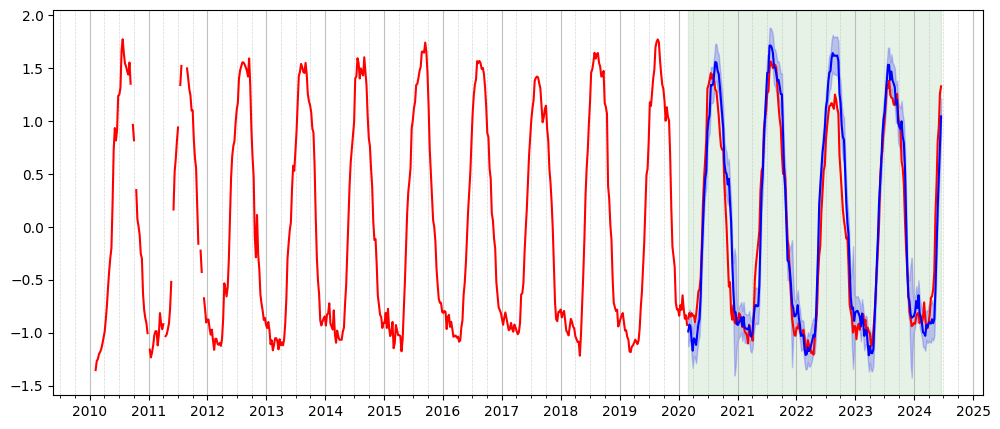

In [8]:
# plt.figure(figsize=(12, 5))
# plt.plot(train_data["time"],train_data["y"], color = "red")
# plt.plot(validation_data["time"],validation_data["y"],color = "red")
# plt.plot(validation_data["time"],mu_validation_preds_optim, color = "blue")

fig, ax = plt.subplots(figsize=(12, 5))
plot_data(
    data_processor=data_processor,
    standardization=True,
    plot_column=output_col,
    validation_label="y",
    plot_train_data=True,
    plot_validation_data=True,
)
plot_prediction(
    data_processor=data_processor,
    mean_validation_pred=mu_validation_preds_optim,
    std_validation_pred=std_validation_preds_optim,
    validation_label=[r"$\mu$", r"$\pm\sigma$"],
)